# Inspect residual pairs

Loads a `pair_truth_eval_detail.parquet` artefact (`blocking.reporting.write_blocking_report()`'s per-pair companion to `pair_truth_eval`'s aggregate name-equality level counts), shows each level's found/missed split, and shows where the misses sit.

`matched_edges` carries predicted pairs only, so a false negative -- the row that actually matters here -- leaves no trace in it at all. `pair_truth_eval_detail` is the artefact that keeps that trace: one row per truth pair (found or missed) plus one row per predicted-but-untrue pair, carrying both sides' raw and cleansed names and the `name_equality` level they fall into: `raw`, `basic`, `cleansed` or `never`, the first name form at which the two sides are equal, or `unknown` when a name is missing on one side.

Every reshape here is a call into `blocking.inspection` (`summarize_pair_outcomes`, `filter_residual_pairs`), not a notebook cell doing its own classification: if something here grows into logic worth trusting, it belongs in `src/blocking/inspection.py` where it can be tested and reused, not in this file.

**Precondition:** a real `execute_blocking_run()` has already written `pair_truth_eval_detail.parquet` for the source/target/representation selected below -- this notebook never runs blocking itself, only discovers and reads what a run already wrote. See cell 2 for the command if none exists yet.

In [ ]:
# --- parameters -------------------------------------------------------------
SOURCE_SYSTEM = "gleif"
TARGET_SYSTEM = "ie"
COUNTRY = "ie"
# The representation the run was made with, one segment of its reference
# blocking://<source>/<target>/<representation>/<key>.
REPRESENTATION = "tfidf"
# The run's key, as run_blocking.py printed it and as the listing below shows
# it. Leave None for the pairing's most recently finished run, by the finish
# time its production record carries.
RUN_KEY = None

# --- what section 5 lists ----------------------------------------------------
# The name-equality level: "never" (cleansed names still differ -- the pairs
# the matcher has to earn), "cleansed", "basic", "raw" (equal at that form),
# "unknown" (a name missing on one side), or None for every row.
NAME_EQUALITY = "never"
IS_TRUTH_PAIR = None  # True | False | None
FOUND = None  # True | False | None
TOP_N = 50  # rows to show in the side-by-side table
# ----------------------------------------------------------------------------

import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))
import _bootstrap  # noqa: F401

from workspace.roots import default_workspace_roots

ROOTS = default_workspace_roots(ROOT)

import polars as pl
from IPython.display import display

from blocking.inspection import summarize_pair_outcomes
from blocking.run_layout import RunArtefact, select_blocking_runs
from workspace.records import read_record
from workspace.reference import reference_at

print(f"ROOT={ROOT}")
print(
    f"SOURCE_SYSTEM={SOURCE_SYSTEM} TARGET_SYSTEM={TARGET_SYSTEM} COUNTRY={COUNTRY} REPRESENTATION={REPRESENTATION}"
)

## 1) Load the `pair_truth_eval_detail` artefact

`pair_truth_eval_detail.parquet` is written by a blocking run; this cell only finds a finished run and reads it back, the same persisted-only convention `notebooks/analyse_corpus_zipf.ipynb` uses for its Zipf fits. A finished run is one holding its production record, so the pairing's runs are selected through `blocking.run_layout.select_blocking_runs` and listed with the settings and finish time each record carries. `RUN_KEY` picks one; left `None`, the most recently finished is read.

If none exists yet, generate one with:

```bash
uv run python scripts/run_blocking.py --source gleif --target ie --representation tfidf --countries ie
```

(substitute `SOURCE_SYSTEM`/`TARGET_SYSTEM`/`REPRESENTATION`/`COUNTRY` above for a different pair). The source dataset must resolve a `matched/` ground-truth layer, since a run with no truth writes no `pair_truth_eval_detail`.


In [ ]:
runs = []
for location in select_blocking_runs(
    ROOTS,
    source_system=SOURCE_SYSTEM,
    target_system=TARGET_SYSTEM,
    representation=REPRESENTATION,
):
    record = read_record(ROOTS, reference_at(ROOTS, location.directory))
    if record is None or not location.path(RunArtefact.PAIR_TRUTH_EVAL_DETAIL).exists():
        continue
    runs.append(
        {
            "run_key": location.directory.name,
            "similarity_backend": record.parameters.get("strategy.similarity_backend"),
            "backend_options": str(record.parameters.get("strategy.backend_options")),
            "finished_at": record.finished_at,
            "location": location,
        }
    )

if not runs:
    raise FileNotFoundError(
        "No finished run with a pair_truth_eval_detail.parquet for "
        f"{SOURCE_SYSTEM} -> {TARGET_SYSTEM} ({REPRESENTATION}). Generate "
        "one with:\n"
        f"  uv run python scripts/run_blocking.py "
        f"--source {SOURCE_SYSTEM} --target {TARGET_SYSTEM} "
        f"--representation {REPRESENTATION} --countries {COUNTRY}"
    )

runs.sort(key=lambda run: run["finished_at"], reverse=True)
display(
    pl.DataFrame([{k: v for k, v in run.items() if k != "location"} for run in runs])
)

if RUN_KEY is None:
    chosen = runs[0]
else:
    chosen = next((run for run in runs if run["run_key"] == RUN_KEY), None)
    if chosen is None:
        raise ValueError(f"RUN_KEY={RUN_KEY!r} names none of the runs listed above")

pair_truth_eval_detail_path = chosen["location"].path(
    RunArtefact.PAIR_TRUTH_EVAL_DETAIL
)
print(f"Loading run {chosen['run_key']}: {pair_truth_eval_detail_path}")
pair_truth_eval_detail = pl.read_parquet(pair_truth_eval_detail_path).filter(
    pl.col("country") == COUNTRY
)
if "name_equality" not in pair_truth_eval_detail.columns:
    raise ValueError(
        f"{pair_truth_eval_detail_path} carries no name_equality column; make "
        "the run again."
    )
print(f"{pair_truth_eval_detail.height:,} rows for country={COUNTRY!r}")

## 2) Found and missed by name-equality level

Two matrices from `blocking.inspection.summarize_pair_outcomes()`, one row per level: `raw`, `basic`, `cleansed`, `never`.

They are two populations, not one, and that is deliberate. A truth pair carries `found`; a predicted-but-untrue pair has `found=None`, because "found" means nothing for a pair that was never true. So **recall** counts truth pairs only, and **precision** counts the predicted set: every `is_truth_pair=False` row plus the truth pairs that were found. There is no single 2x2 confusion matrix available here — true negatives are every unproposed pair in the cross product, which this artefact does not and could not enumerate.

A level is a partition of the truth pairs, not a prediction: it says at which name form the two sides first become equal. Its recall is blocking's recall within that slice, and there is no coarse easy/difficult fold any more, since folding levels together only hides which one a pair sat at. The `never` level is the residual the matcher actually has to earn.

> **Treat the levels as indicative, not settled.** They are computed from each side's materialized `name_cleansed`, while the matcher scores the raw `name` — so a pair can land in `never` purely because two systems' cleanse configs disagree (`limited` vs `ltd`) and then be recovered trivially. On a real `gleif -> gb` run, 3,300 of 6,724 `never` truth pairs had raw names identical ignoring case.

In [3]:
outcomes = summarize_pair_outcomes(pair_truth_eval_detail)

pairs = pair_truth_eval_detail

for key, title in (
    ("recall", "TRUTH PAIRS -- did we find it?"),
    ("precision", "PREDICTED PAIRS -- was it real?"),
):
    print(f"\n{title}")
    display(outcomes[key])

print("\nrow counts by name_equality")
display(pairs.group_by("name_equality").len().sort("len", descending=True))


TRUTH PAIRS -- did we find it?


name_equality,found,missed,total,recall
str,i64,i64,i64,f64
"""raw""",12237,0,12237,1.0
"""basic""",4752,72,4824,0.985075
"""cleansed""",254,748,1002,0.253493
"""never""",128,914,1042,0.122841



PREDICTED PAIRS -- was it real?


name_equality,true_pair,false_pair,total,precision
str,i64,i64,i64,f64
"""raw""",12237,32,12269,0.997392
"""basic""",4752,32,4784,0.993311
"""cleansed""",254,1,255,0.996078
"""never""",128,3202,3330,0.038438



row counts by name_equality


name_equality,len
str,u32
"""raw""",12269
"""basic""",4856
"""never""",4244
"""cleansed""",1003


## 3) Per-pair distance statistics

Levenshtein distance, token-set Jaccard, and token-count delta between each pair's *cleansed* names, computed over the **whole** frame so sections 4 and 5 can both draw on them. Computed here rather than persisted in `pair_truth_eval_detail.parquet`: that artefact keeps to the per-pair classification the name-equality levels are built from, not a second set of derived metrics with no stable "correct" value the way a level assignment has.

Tokenization reuses `scripts/measure_initialism_recall.py`'s `_tokenize()` (plain whitespace split, the same convention that script's own initialism measurement uses) rather than a second tokenizer.

In [4]:
import jellyfish

from scripts.measure_initialism_recall import _tokenize


def _distance_stats(
    source_name: str | None, target_name: str | None
) -> dict[str, float | int | None]:
    source_tokens = set(_tokenize(source_name))
    target_tokens = set(_tokenize(target_name))
    union = source_tokens | target_tokens
    jaccard = len(source_tokens & target_tokens) / len(union) if union else None
    levenshtein = (
        jellyfish.levenshtein_distance(source_name, target_name)
        if source_name and target_name
        else None
    )
    return {
        "levenshtein_distance": levenshtein,
        "token_jaccard": jaccard,
        "token_count_delta": abs(len(source_tokens) - len(target_tokens)),
    }


stats_rows = [
    _distance_stats(row["source_name_cleansed"], row["target_name_cleansed"])
    for row in pairs.iter_rows(named=True)
]
pairs = pairs.with_columns(
    pl.Series(
        "levenshtein_distance",
        [r["levenshtein_distance"] for r in stats_rows],
        dtype=pl.Int64,
    ),
    pl.Series(
        "token_jaccard",
        [r["token_jaccard"] for r in stats_rows],
        dtype=pl.Float64,
    ),
    pl.Series(
        "token_count_delta",
        [r["token_count_delta"] for r in stats_rows],
        dtype=pl.Int64,
    ),
)
print(f"distance statistics computed for {pairs.height:,} rows")

distance statistics computed for 22,372 rows


## 4) Where the misses sit

Truth pairs at the `never` level only, since `found` means nothing for a pair that was never true and the other levels are equal by the time cleansing has run. Each picture puts found against missed on one axis, so you can see whether misses concentrate at a particular distance or are spread across the range.

Levenshtein is capped at 20, so the last bar reads "20 or more". Jaccard is bucketed in tenths: 0.0 means the two cleansed names share no whitespace token at all, 1.0 means identical token sets in a different order or with different spacing.

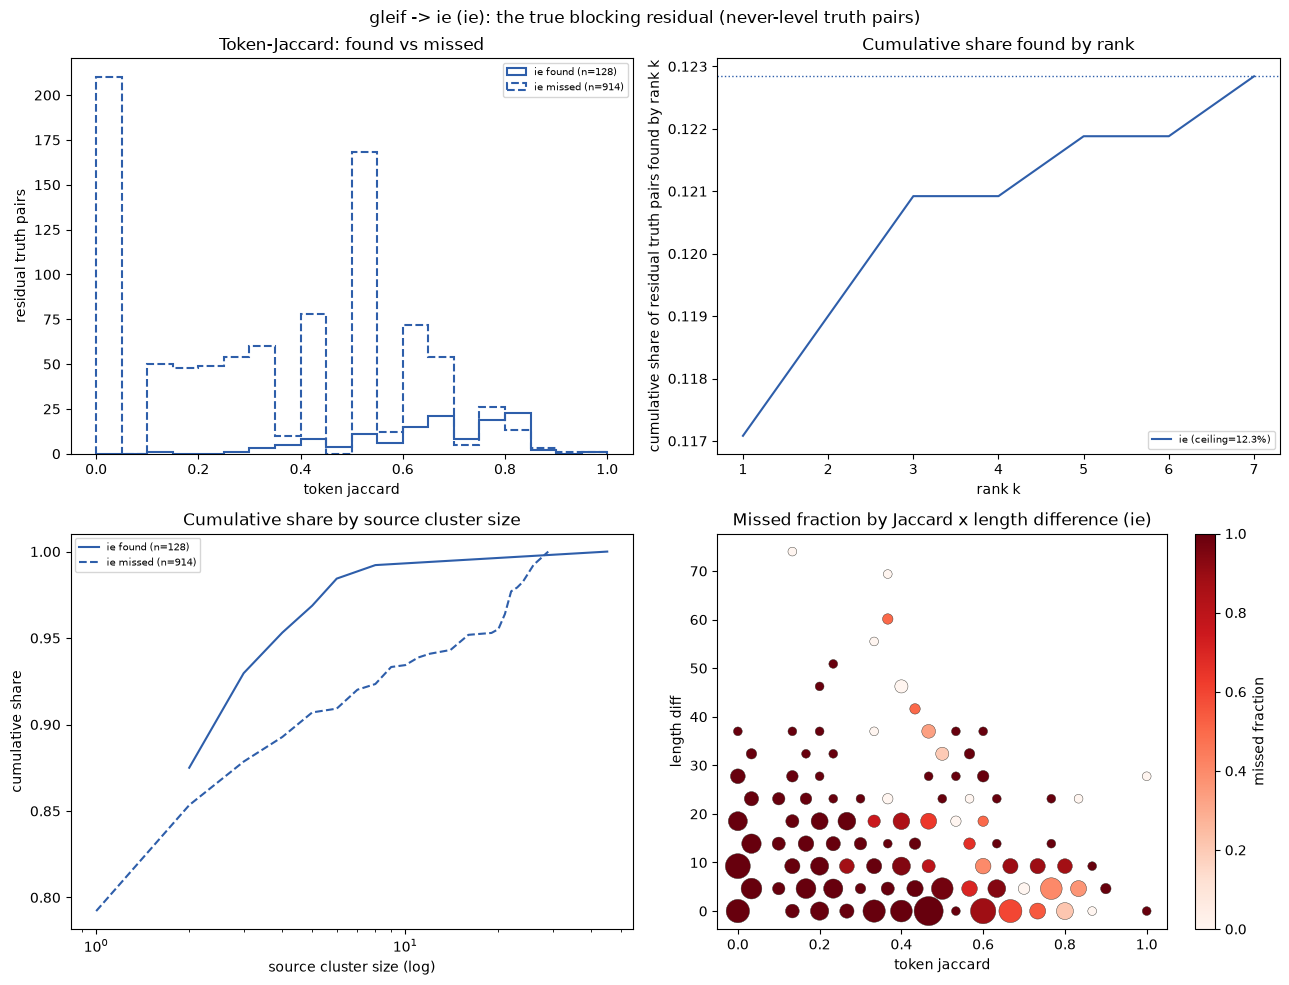

In [5]:
import matplotlib.pyplot as plt

from analysis.residual_pictures import (
    build_residual_picture_frame,
    draw_axis_histogram,
    draw_cluster_size_cumulative,
    draw_missed_fraction_hex,
    draw_recall_by_rank,
)

# analysis.residual_pictures forces the Agg backend at import time (its
# script caller writes straight to PNG); switch to the notebook backend after
# importing it so figures render inline, same convention as
# notebooks/analyse_corpus_zipf.ipynb's token_zipf cell.
%matplotlib inline

# The four pictures over the true blocking residual (never-level truth pairs
# found vs missed), drawn through analysis.residual_pictures rather than
# reimplemented here -- see that module for what each axis measures.
picture_frame = build_residual_picture_frame(
    pair_truth_eval_detail_path.parent, country=COUNTRY
)
picture_series = [(COUNTRY, picture_frame)]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
draw_axis_histogram(axes[0][0], picture_series, title="Token-Jaccard: found vs missed")
draw_recall_by_rank(axes[0][1], picture_series, title="Cumulative share found by rank")
draw_cluster_size_cumulative(
    axes[1][0], picture_series, title="Cumulative share by source cluster size"
)
draw_missed_fraction_hex(
    axes[1][1],
    picture_frame,
    title=f"Missed fraction by Jaccard x length difference ({COUNTRY})",
)
fig.suptitle(
    f"{SOURCE_SYSTEM} -> {TARGET_SYSTEM} ({COUNTRY}): the true blocking residual "
    "(never-level truth pairs)"
)
fig.tight_layout()
plt.show()

## 5) List the matches

`show()` is the one call for pulling up rows. With no arguments it uses the `NAME_EQUALITY`/`IS_TRUTH_PAIR`/`FOUND` parameters from the top of the notebook; pass any of them directly to override without re-running anything above:

```python
show("never")                                  # every still-unequal pair
show("cleansed", found=False)                  # pairs cleansing equalises that we still missed
show("never", is_truth_pair=True, found=False) # the misses that matter
show("never", is_truth_pair=False)             # candidate-set pollution
show(None, sort_by="token_jaccard")            # everything, weakest overlap first
```

Default sort is Levenshtein ascending, so the closest pairs come first — for a miss those are the most informative, since a near-identical pair the run failed to recover points at a specific representation gap rather than genuine name divergence.

In [6]:
LIST_COLUMNS = [
    "name_equality",
    "is_truth_pair",
    "found",
    "similarity",
    "source_name",
    "target_name",
    "source_name_cleansed",
    "target_name_cleansed",
    "levenshtein_distance",
    "token_jaccard",
    "token_count_delta",
]


def show(
    name_equality: str | None = NAME_EQUALITY,
    *,
    is_truth_pair: bool | None = IS_TRUTH_PAIR,
    found: bool | None = FOUND,
    n: int = TOP_N,
    sort_by: str = "levenshtein_distance",
    descending: bool = False,
):
    """Display up to `n` pairs, filtered and sorted. Returns the filtered
    frame (before the `n` cap) so a caller can keep working with it."""
    frame = pairs
    if name_equality is not None:
        frame = frame.filter(pl.col("name_equality") == name_equality)
    if is_truth_pair is not None:
        frame = frame.filter(pl.col("is_truth_pair") == is_truth_pair)
    if found is not None:
        frame = frame.filter(pl.col("found") == found)

    print(
        f"{SOURCE_SYSTEM} -> {TARGET_SYSTEM} ({COUNTRY}): {frame.height:,} rows "
        f"(name_equality={name_equality!r}, is_truth_pair={is_truth_pair!r}, "
        f"found={found!r}) -- showing up to {n} by {sort_by}"
    )
    with pl.Config(tbl_cols=-1, tbl_rows=n, fmt_str_lengths=60):
        display(
            frame.select(LIST_COLUMNS)
            .sort(sort_by, descending=descending, nulls_last=True)
            .head(n)
        )
    return frame


show()

gleif -> ie (ie): 4,244 rows (name_equality='never', is_truth_pair=None, found=None) -- showing up to 50 by levenshtein_distance


name_equality,is_truth_pair,found,similarity,source_name,target_name,source_name_cleansed,target_name_cleansed,levenshtein_distance,token_jaccard,token_count_delta
str,bool,bool,f64,str,str,str,str,i64,f64,i64
"""never""",true,false,null,"""McNulty's Carpet & Furniture World Limited""","""MC NULTY'S CARPET & FURNITURE WORLD LIMITED""","""mcnulty s carpet & furniture world ltd""","""mc nulty s carpet & furniture world ltd""",1,0.666667,1
"""never""",true,false,null,"""McCaughan Paper ltd""","""MC CAUGHAN PAPER LIMITED""","""mccaughan paper ltd""","""mc caughan paper ltd""",1,0.4,1
"""never""",true,false,null,"""OMordha Construction Ltd""","""O'MORDHA CONSTRUCTION LIMITED""","""omordha construction ltd""","""o mordha construction ltd""",1,0.4,1
"""never""",true,false,null,"""L-Tec Engineering Limited""","""L-TECH ENGINEERING LIMITED""","""l tec engineering ltd""","""l tech engineering ltd""",1,0.6,0
"""never""",true,false,null,"""Connolly's Organic Eggs Limited""","""CONNOLLYS ORGANIC EGGS LIMITED""","""connolly s organic eggs ltd""","""connollys organic eggs ltd""",1,0.5,1
"""never""",true,false,null,"""PacSane Limited""","""PAC SANE LIMITED""","""pacsane ltd""","""pac sane ltd""",1,0.25,1
"""never""",true,false,null,"""Athena Securities 1 DAC""","""ATHENA SECURITIES I DESIGNATED ACTIVITY COMPANY""","""athena securities 1 dac""","""athena securities i dac""",1,0.6,0
"""never""",true,false,null,"""Key Arklow Investment Limited""","""KEY ARKLOW INVESTMENTS LIMITED""","""key arklow investment ltd""","""key arklow investments ltd""",1,0.6,0
"""never""",true,false,null,"""Smyths Toys EUHQ UC""","""SMYTHS TOYS EU HQ UNLIMITED COMPANY""","""smyths toys euhq uc""","""smyths toys eu hq uc""",1,0.5,1


source_system,target_system,country,source_id,target_id,source_name,source_name_cleansed,target_name,target_name_cleansed,name_equality,is_truth_pair,found,similarity,rank,levenshtein_distance,token_jaccard,token_count_delta
str,str,str,str,str,str,str,str,str,str,bool,bool,f64,i64,i64,f64,i64
"""gleif""","""ie""","""ie""","""gleif://635400KEZ3OHK4M36438""","""ie://292644""","""McNulty's Carpet & Furniture W…","""mcnulty s carpet & furniture w…","""MC NULTY'S CARPET & FURNITURE …","""mc nulty s carpet & furniture …","""never""",true,false,null,null,1,0.666667,1
"""gleif""","""ie""","""ie""","""gleif://635400IX2SBS3SXGEG61""","""ie://72667""","""Endress & Hauser (Ireland) Lim…","""endress & hauser ireland ltd""","""ENDRESS + HAUSER (IRELAND) LIM…","""endress hauser ireland ltd""","""never""",true,true,1.0,1,2,0.8,1
"""gleif""","""ie""","""ie""","""gleif://63540089ASRSM9BCGZ97""","""ie://90693""","""Barry McGrath Pension Trust""","""barry mcgrath pension trust""","""BANTRY TIMBER MOULDINGS LIMITE…","""bantry timber mouldings ltd""","""never""",true,false,null,null,21,0.0,0
"""gleif""","""ie""","""ie""","""gleif://635400LCWZMNTYTAQV37""","""ie://319650""","""Academy Plaza Hotel Partnershi…","""academy plaza hotel partnershi…","""RADIOLOGY SYSTEMS LIMITED""","""radiology systems ltd""","""never""",true,false,null,null,24,0.0,1
"""gleif""","""ie""","""ie""","""gleif://635400V1HDR4Z3QAHT51""","""ie://504015""","""THE ECOGNOME PARTNERSHIP""","""the ecognome partnership""","""POROSA TILE DISTRIBUTION LIMIT…","""porosa tile distribution ltd""","""never""",true,false,null,null,25,0.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""gleif""","""ie""","""ie""","""gleif://635400XO574BY6KTWX71""","""ie://686825""","""TALITECH UNLIMITED COMPANY""","""talitech uc""","""F.A.F.C UNLIMITED COMPANY""","""fafc uc""","""never""",false,null,1.0,3,6,0.333333,0
"""gleif""","""ie""","""ie""","""gleif://254900OFKE0VYTMS2K85""","""ie://610540""","""Sprite Aviation No.1 Designate…","""sprite aviation no 1 dac""","""SPRITE AVIATION NO.3 DESIGNATE…","""sprite aviation no 3 dac""","""never""",false,null,1.0,7,1,0.666667,0
"""gleif""","""ie""","""ie""","""gleif://6354007DVB2OTKCVEU40""","""ie://689693""","""Fintrax Treasury Services Desi…","""fintrax treasury services dac""","""KYNDRYL TREASURY SERVICES DESI…","""kyndryl treasury services dac""","""never""",false,null,0.768989,3,5,0.6,0


## Interpretation checklist

- A low Levenshtein distance with zero token overlap is usually the same company under an alternate spelling or an abbreviation the current representation doesn't reach.
- A high token-count delta with a nonzero `token_jaccard` is often a subsidiary/branch relationship ("Acme UK" vs "Acme UK Holdings Ltd").
- `is_truth_pair=False` rows are candidate-set pollution: check whether the predicted `similarity` sits close to the run's `min_similarity` threshold, which would suggest tightening it costs little recall.
- A `never` pair whose *raw* names differ only in case or punctuation is not hard at all -- it is the two systems' cleanse configs disagreeing. Check `source_name` against `target_name` before treating a miss as a representation gap.
- Re-run after a representation/tokenizer change to see whether specific pairs move between found and missed within a level, not just whether the aggregate `pair_truth_eval` recall moved. A pair's level is a property of its names, so it never moves level on its own.